# Machine Learning per l’Analisi Finanziaria

## Lezione 01 — Il churn come problema di classificazione: formulazione e analisi esplorativa

**Authors:**
- Enrico Huber
- Pietro Soglia

**Last updated:** 2026-03-05

## Obiettivi di apprendimento

- Tradurre un problema di business (churn) in un problema di classificazione binaria.
- Identificare target e feature, distinguendo variabili predittive da identificativi.
- Condurre un’EDA essenziale: target, statistiche descrittive, sbilanciamento, prime ipotesi.
- Riconoscere variabili non predittive che si comportano come rumore casuale.
- Riconoscere segnali di **data leakage** e variabili “proxy” del target.
- Formulare ipotesi su quali variabili possano essere predittive del churn, basandosi su evidenze quantitative.

## Outline

1. Setup, contesto e riproducibilità
2. Formulazione del problema: dal business al ML
3. Caricamento dati e validazione schema
4. Definire il target e quantificare lo sbilanciamento
5. Qualità del dato: tipi, range, controlli rapidi
6. Feature numeriche: distribuzioni e differenze tra classi
7. Variabili a basso potere predittivo (rumore statistico)
   (EstimatedSalary, Satisfaction Score)
8. Feature categoriche: churn rate per gruppi
   (Geography, Gender, Card Type)
9. Segmentazioni e interazioni: pattern di churn per gruppi e fasce
   (IsActiveMember, HasCrCard, NumOfProducts, fasce d'età, Geography × Gender)
10. Correlazioni e ridondanza tra feature numeriche
    (heatmap Pearson, ranking feature senza leakage)
11. Attenzione al leakage: il caso `Complain`
12. Baseline minimale
    (DummyClassifier, Logistic Regression, Confusion Matrix, ROC Curve)
13. Riepilogo

## 2. Formulazione del problema: dal business al ML

Prima di aprire qualsiasi file di dati, formalizziamo il problema in termini matematici.
Questo passaggio evita ambiguità e obbliga a rendere esplicite le assunzioni chiave.

### Il churn in ambito bancario

Il **churn** (abbandono) si verifica quando un cliente decide di chiudere il proprio
conto o di cessare il rapporto con la banca. Prevedere il churn in anticipo consente
di attivare azioni di *retention* (offerte, supporto, contatto proattivo) prima che
il cliente se ne vada.

### Formalizzazione come classificazione binaria

Dato un insieme di **osservazioni** (clienti), definiamo:

- $X \in \mathbb{R}^{n \times p}$: la matrice delle **feature** (dati demografici,
  comportamento bancario, ecc.);
- $y \in \{0, 1\}^n$: il vettore **target**, dove $y_i = 1$ indica che il
  cliente $i$ ha effettuato il churn;
- $\hat{p}(y=1 \mid X_i)$: la probabilità stimata di churn per il cliente $i$.

L'obiettivo è apprendere una funzione $f: X \mapsto \hat{p}$ che massimizzi la
**ROC-AUC** su dati non visti.

### Vincoli e rischi principali

| Rischio | Descrizione |
|---------|-------------|
| **Data leakage** | Feature "post-evento": informazioni note solo *dopo* il churn (es. reclami chiusi al momento della cancellazione). |
| **Target drift** | La definizione di churn può cambiare nel tempo (es. soglia di inattività). |
| **Imbalance** | La classe $y=1$ è tipicamente minoritaria; l'accuracy da sola non è la metrica giusta. |
| **Generalizzazione** | Il modello deve performare su clienti *futuri*, non solo sul training set. |

## Setup

Definiamo dipendenze, percorsi e cartelle di output.

In [19]:
from __future__ import annotations

import random
from pathlib import Path
from zipfile import ZipFile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        print(x)


SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""

    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)

    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate

    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_ARCHIVE_PATH = ROOT / "data" / "archive.zip"
OUTPUTS_DIR = ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for _dir in [OUTPUTS_DIR, FIGURES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")


def load_dataset_from_archive(
    archive_path: Path,
    filename_patterns: tuple[str, ...] = ("train", "test", "churn", "customer"),
) -> pd.DataFrame:
    """Carica il CSV principale dall'archivio ZIP validando lo schema.

    La funzione:
    - controlla che l'archivio esista;
    - lista i membri;
    - sceglie il primo CSV compatibile con i pattern;
    - legge il CSV direttamente dallo ZIP.
    """

    if not archive_path.exists():
        raise FileNotFoundError(f"Archivio dati non trovato: {archive_path}")

    with ZipFile(archive_path) as zf:
        members = [m for m in zf.namelist() if not m.endswith("/")]
        print("Membri archivio:")
        for m in members:
            print(f"  - {m}")

        candidates = [
            m
            for m in members
            if any(p in m.lower() for p in filename_patterns) and m.endswith(".csv")
        ]
        if not candidates:
            raise FileNotFoundError(
                "Nessun CSV trovato nell'archivio con i pattern "
                f"{filename_patterns}. Membri disponibili: {members}"
            )

        chosen = candidates[0]
        print(f"\nFile selezionato: {chosen}")

        with zf.open(chosen) as f:
            return pd.read_csv(f)

## Caricamento dati e contratto del dataset

Iniziamo validando il “contratto” del dataset: dove si trova, quali colonne contiene,
che tipi di variabili abbiamo e quale colonna può essere il target.

In [20]:
df = load_dataset_from_archive(DATA_ARCHIVE_PATH)

print("\nShape:", df.shape)
display(df.head())

print("\nDtypes:")
display(df.dtypes)

print("\nDescrittive (numeriche):")
display(df.describe(include=[np.number]).T)

Membri archivio:
  - Customer-Churn-Records.csv

File selezionato: Customer-Churn-Records.csv

Shape: (10000, 18)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425



Dtypes:


RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object


Descrittive (numeriche):


,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.00,5000.50,2886.90,1.00,2500.75,5000.50,7500.25,10000.00
CustomerId,10000.00,15690940.57,71936.19,15565701.00,15628528.25,15690738.00,15753233.75,15815690.00
CreditScore,10000.00,650.53,96.65,350.00,584.00,652.00,718.00,850.00
Age,10000.00,38.92,10.49,18.00,32.00,37.00,44.00,92.00
Tenure,10000.00,5.01,2.89,0.00,3.00,5.00,7.00,10.00
Balance,10000.00,76485.89,62397.41,0.00,0.00,97198.54,127644.24,250898.09
NumOfProducts,10000.00,1.53,0.58,1.00,1.00,1.00,2.00,4.00
HasCrCard,10000.00,0.71,0.46,0.00,0.00,1.00,1.00,1.00
IsActiveMember,10000.00,0.52,0.50,0.00,0.00,1.00,1.00,1.00
EstimatedSalary,10000.00,100090.24,57510.49,11.58,51002.11,100193.91,149388.25,199992.48


- Il dataset contiene **10,000 righe** e **18 colonne**.
- La colonna `Exited` è la variabile binaria (0/1) target che indica se il cliente ha effettuato il churn.
- Sono presenti anche colonne identificative (`RowNumber`, `CustomerId`, `Surname`) che non dovrebbero essere usate per “prevedere”, ma possono servire per controlli e join (se esistessero altre tabelle).

## Definire il target e quantificare lo sbilanciamento

In problemi di churn è tipico che la classe positiva (chi abbandona) sia minoritaria.
Quantifichiamo quindi la prevalenza di `Exited=1`.

Target counts:
 Exited
0    7962
1    2038
Name: count, dtype: int64

Target rates:
 Exited
0   0.80
1   0.20
Name: proportion, dtype: float64


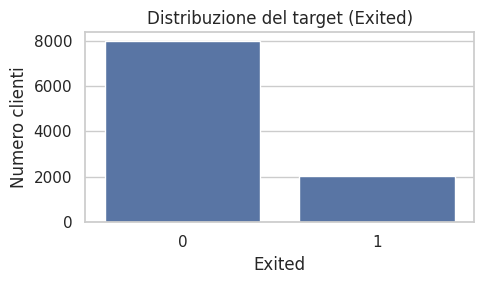

In [21]:
TARGET = "Exited"

target_counts = df[TARGET].value_counts().sort_index()
target_rates = df[TARGET].value_counts(normalize=True).sort_index()

print("Target counts:\n", target_counts)
print("\nTarget rates:\n", target_rates)

plt.figure(figsize=(5, 3))
ax = sns.barplot(x=target_counts.index.astype(str), y=target_counts.values)
ax.set_title("Distribuzione del target (Exited)")
ax.set_xlabel("Exited")
ax.set_ylabel("Numero clienti")

save_current_figure("lesson_01_target_distribution.png")
plt.show()

- `Exited=1` (churn) vale **2,038 / 10,000 = 20.38%**: la classe positiva è minoritaria ma non estremamente rara.
- `Exited=0` vale **7,962 / 10,000 = 79.62%**.
- Lo sbilanciamento suggerisce di usare metriche robuste (es. ROC-AUC) e split stratificati.

## Qualità del dato: tipi, range, controlli rapidi

Prima di qualsiasi modello, controlliamo: valori mancanti, duplicati, e la presenza di colonne “sospette”
(es. variabili che potrebbero essere note solo dopo l’evento di churn).

In [22]:
missing_rate = df.isna().mean().sort_values(ascending=False)
duplicated_rows = df.duplicated().sum()
duplicated_customer_id = (
    df["CustomerId"].duplicated().sum() if "CustomerId" in df.columns else None
)

print("Duplicated rows:", duplicated_rows)
print("Duplicated CustomerId:", duplicated_customer_id)

print("\nTop missing (dovrebbe essere tutto 0):")
display(missing_rate.head(12))

id_cols = [c for c in ["RowNumber", "CustomerId", "Surname"] if c in df.columns]
print("\nColonne identificative candidate:", id_cols)

Duplicated rows: 0
Duplicated CustomerId: 0

Top missing (dovrebbe essere tutto 0):


RowNumber        0.00
CustomerId       0.00
Surname          0.00
CreditScore      0.00
Geography        0.00
Gender           0.00
Age              0.00
Tenure           0.00
Balance          0.00
NumOfProducts    0.00
HasCrCard        0.00
IsActiveMember   0.00
dtype: float64


Colonne identificative candidate: ['RowNumber', 'CustomerId', 'Surname']


- Non risultano valori mancanti: il tasso di missing è **0** per tutte le colonne.
- Non risultano righe duplicate (duplicati = **0**).
- `CustomerId` è un identificativo: anche se unico, non è informazione “causale” e in genere va escluso dal modeling.

## Feature numeriche: distribuzioni e differenze tra classi

Confrontiamo alcune feature numeriche tra `Exited=0` e `Exited=1`.
L’obiettivo non è “dimostrare causalità”, ma generare ipotesi utili per la modellazione.

Age quantiles by target:
         0.25  0.50  0.75
Exited                  
0      31.00 36.00 41.00
1      38.00 45.00 51.00

Share Balance==0: 0.3617
Churn rate Balance==0: 0.13823610727121924
Churn rate Balance>0: 0.2409525301582328


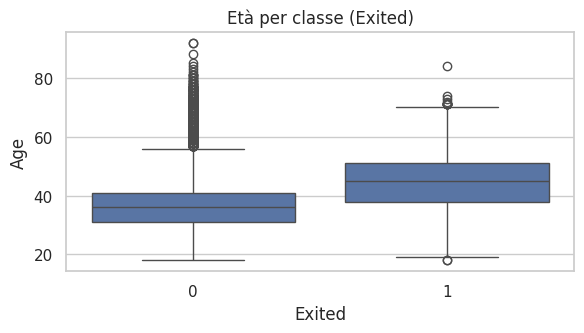

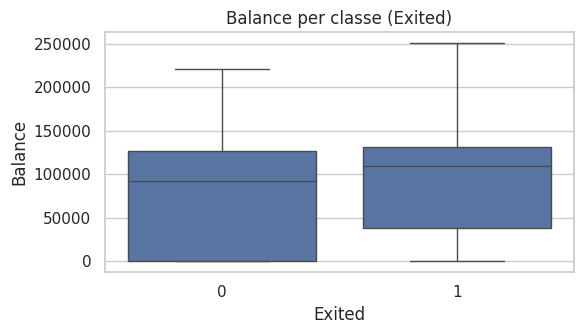

In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

age_quantiles = df.groupby(TARGET)["Age"].quantile([0.25, 0.5, 0.75]).unstack()

balance_zero_share = (df["Balance"] == 0).mean()
churn_rate_balance_zero = df.loc[df["Balance"] == 0, TARGET].mean()
churn_rate_balance_positive = df.loc[df["Balance"] > 0, TARGET].mean()

print("Age quantiles by target:\n", age_quantiles)
print("\nShare Balance==0:", balance_zero_share)
print("Churn rate Balance==0:", churn_rate_balance_zero)
print("Churn rate Balance>0:", churn_rate_balance_positive)

plt.figure(figsize=(6, 3.5))
ax = sns.boxplot(data=df, x=TARGET, y="Age")
ax.set_title("Età per classe (Exited)")
ax.set_xlabel("Exited")
ax.set_ylabel("Age")

save_current_figure("lesson_01_age_by_target.png")
plt.show()

plt.figure(figsize=(6, 3.5))
ax = sns.boxplot(data=df, x=TARGET, y="Balance")
ax.set_title("Balance per classe (Exited)")
ax.set_xlabel("Exited")
ax.set_ylabel("Balance")

save_current_figure("lesson_01_balance_by_target.png")
plt.show()

- L’età è più alta nei clienti churn: la **mediana** passa da **36** (`Exited=0`) a **45** (`Exited=1`).
- La feature `Balance` ha un comportamento interessante: **36.17%** dei clienti ha `Balance==0`.
- Il churn rate per `Balance==0` è **13.82%**, mentre per `Balance>0` è **24.10%**: il saldo non nullo sembra associato a maggior churn (ipotesi da validare).


`Balance` presenta una distribuzione **bimodale**: circa il 36% dei clienti ha saldo zero,
mentre la restante parte ha densità concentrata intorno a ~100.000 EUR.
Visualizziamo la distribuzione del saldo **positivo** separata per classe target.

/tmp/ipykernel_7148/1186514948.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title="Exited")


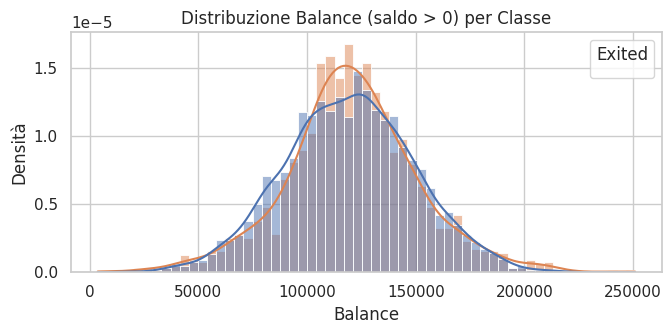

In [24]:
plt.figure(figsize=(7, 3.5))
ax = sns.histplot(
    data=df[df["Balance"] > 0],
    x="Balance",
    hue=TARGET,
    kde=True,
    common_norm=False,
    stat="density",
)
ax.set_title("Distribuzione Balance (saldo > 0) per Classe")
ax.set_xlabel("Balance")
ax.set_ylabel("Densità")
ax.legend(title="Exited")
save_current_figure("lesson_01_balance_positive_distribution.png")
plt.show()

- Tra i clienti con **saldo positivo**, le distribuzioni delle due classi si sovrappongono
  fortemente: la differenza non sta nella forma della distribuzione, ma nella *quota di saldo zero*.
- I clienti con `Balance==0` hanno churn rate **~14%** vs **~24%** per `Balance>0`.
- Questa bimodalità suggerisce di creare una feature ingegnerizzata `balance_is_zero`
  nella fase di preprocessing (Lezione 2).

### CreditScore e Tenure

Completiamo l'analisi delle feature numeriche con `CreditScore` (punteggio di credito)
e `Tenure` (anni di permanenza in banca).

CreditScore per classe target:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.00,651.84,95.65,405.00,585.00,653.00,718.00,850.00
1,2038.00,645.41,100.34,350.00,578.00,646.00,716.00,850.00



Tenure per classe target:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.00,5.03,2.88,0.00,3.00,5.00,7.00,10.00
1,2038.00,4.93,2.94,0.00,2.00,5.00,8.00,10.00


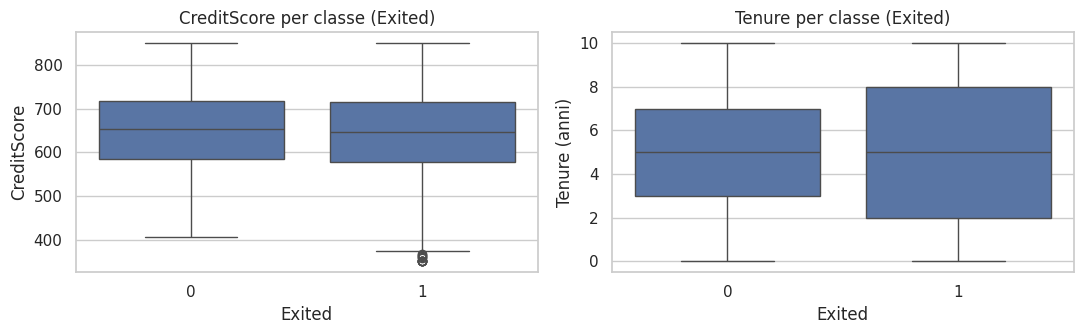

In [25]:
credit_stats = df.groupby(TARGET)["CreditScore"].describe()
tenure_stats = df.groupby(TARGET)["Tenure"].describe()

print("CreditScore per classe target:")
display(credit_stats)
print("\nTenure per classe target:")
display(tenure_stats)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

sns.boxplot(data=df, x=TARGET, y="CreditScore", ax=axes[0])
axes[0].set_title("CreditScore per classe (Exited)")
axes[0].set_xlabel("Exited")
axes[0].set_ylabel("CreditScore")

sns.boxplot(data=df, x=TARGET, y="Tenure", ax=axes[1])
axes[1].set_title("Tenure per classe (Exited)")
axes[1].set_xlabel("Exited")
axes[1].set_ylabel("Tenure (anni)")

plt.tight_layout()
save_current_figure("lesson_01_creditscore_tenure_by_target.png")
plt.show()

- **`CreditScore`**: le mediane sono praticamente identiche (~650 per entrambe le classi),
  le distribuzioni si sovrappongono quasi completamente. Il punteggio di credito non è
  un predittore significativo del churn "da solo".
- **`Tenure`**: anch'essa distribuita in modo simile tra le classi, con mediana ~5 anni
  per entrambi i gruppi. La fedeltà storica da sola non predice il churn futuro.
- Entrambe le feature potrebbero rivelarsi utili solo in combinazione con altre variabili
  (interazioni, feature engineering) nelle lezioni successive.

## Variabili a basso potere predittivo (Rumore statistico)

Non tutte le feature raccolte offrono reale discriminazione rispetto al target. A volte, alcune variabili rappresentano puro “rumore” statistico, o sono generate in modo sostanzialmente uniforme e scorrelato dalla propensione al churn.

Esaminiamo `EstimatedSalary` e `Satisfaction Score`.

Descrittive di EstimatedSalary divise per classe target:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7962.00,99726.85,57399.96,90.07,50783.29,99620.35,148602.45,199992.48
1,2038.00,101509.91,57932.62,11.58,51924.02,102489.33,152443.86,199808.10



Churn rate per Satisfaction Score:


,churn_rate,n
Satisfaction Score,,
1,0.20,1932
2,0.22,2014
3,0.20,2042
4,0.21,2008
5,0.20,2004


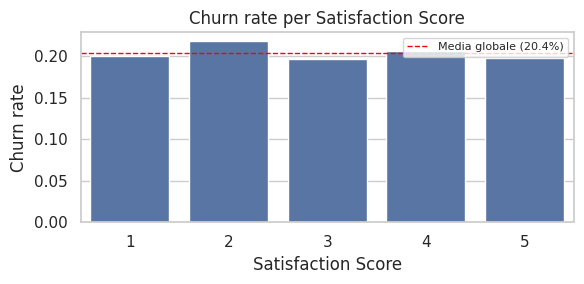

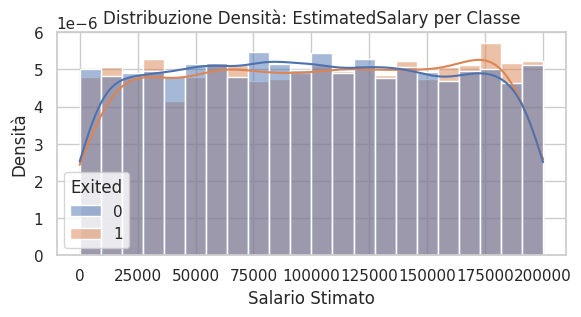

In [26]:
salary_churn_rates = df.groupby(TARGET)["EstimatedSalary"].describe()
print("Descrittive di EstimatedSalary divise per classe target:")
display(salary_churn_rates)

# Calcoliamo il churn per punteggio di soddisfazione (1 a 5)
if "Satisfaction Score" in df.columns:
    sat_score_churn = (
        df.groupby("Satisfaction Score")[TARGET]
        .mean()
        .rename("churn_rate")
        .to_frame()
        .join(df["Satisfaction Score"].value_counts().rename("n"))
        .sort_index()
    )
    print("\nChurn rate per Satisfaction Score:")
    display(sat_score_churn)

    # Visualizzazione: il churn rate è piatto rispetto al punteggio di soddisfazione
    plt.figure(figsize=(6, 3))
    ax_sat = sns.barplot(
        x=sat_score_churn.index.astype(str),
        y=sat_score_churn["churn_rate"].values,
    )
    ax_sat.set_title("Churn rate per Satisfaction Score")
    ax_sat.set_xlabel("Satisfaction Score")
    ax_sat.set_ylabel("Churn rate")
    ax_sat.axhline(
        df[TARGET].mean(),
        linestyle="--",
        color="red",
        linewidth=1,
        label=f"Media globale ({df[TARGET].mean():.1%})",
    )
    ax_sat.legend(fontsize=8)
    save_current_figure("lesson_01_churn_rate_by_satisfaction.png")
    plt.show()

plt.figure(figsize=(6, 3.5))
ax = sns.histplot(
    data=df,
    x="EstimatedSalary",
    hue=TARGET,
    kde=True,
    common_norm=False,
    stat="density",
)
ax.set_title("Distribuzione Densità: EstimatedSalary per Classe")
ax.set_xlabel("Salario Stimato")
ax.set_ylabel("Densità")

save_current_figure("lesson_01_salary_distribution.png")
plt.show()

- `EstimatedSalary` è uniformemente distribuita su tutto il dominio (da ~€11 a ~€200,000) e la sua
  distribuzione è praticamente **identica** nelle due popolazioni: il salario stimato da solo
  non è un predittore del churn.
- Il `Satisfaction Score` (bar chart sopra) conferma questa valutazione visivamente:
  il churn rate oscilla in modo casuale attorno alla media globale (~20%) senza
  alcun trend monotono (né crescente né decrescente). Non vi è alcun segnale di
  correlazione con la soddisfazione del cliente.

**Nota importante:** Variabili simili non devono essere eliminate aprioristicamente: potrebbero emergere segnali in interazione con altre feature, ma vanno trattate con bassa priorità.

## Feature categoriche: churn rate per gruppi

Alcune variabili descrivono gruppi (es. area geografica) e possono mostrare tassi di churn differenti.
Calcoliamo il churn rate per gruppo per `Geography`, `Gender` e `Card Type`.

Colonne categoriche candidate: ['Geography', 'Gender', 'Card Type']

Geography (n, churn_rate):


,churn_rate,n
Geography,,
Germany,0.32,2509
Spain,0.17,2477
France,0.16,5014



Gender (n, churn_rate):


,churn_rate,n
Gender,,
Female,0.25,4543
Male,0.16,5457



Card Type (n, churn_rate):


,churn_rate,n
Card Type,,
DIAMOND,0.22,2507
PLATINUM,0.20,2495
SILVER,0.20,2496
GOLD,0.19,2502


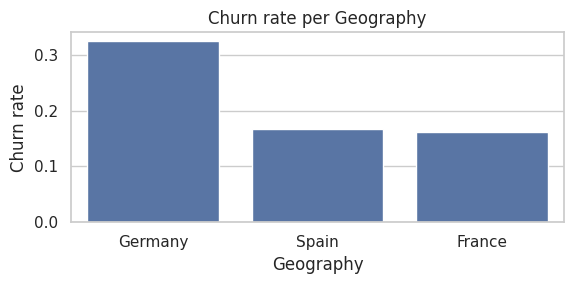

In [27]:
from pandas.api.types import is_numeric_dtype

cat_cols: list[str] = []
for c in df.columns:
    if c == TARGET:
        continue
    if c in {"RowNumber", "CustomerId", "Surname"}:
        continue
    if not is_numeric_dtype(df[c]):
        cat_cols.append(c)

print("Colonne categoriche candidate:", cat_cols)

for c in ["Geography", "Gender", "Card Type"]:
    if c in df.columns:
        out = (
            df.groupby(c)[TARGET]
            .mean()
            .rename("churn_rate")
            .to_frame()
            .join(df[c].value_counts().rename("n"))
            .sort_values("churn_rate", ascending=False)
        )
        print(f"\n{c} (n, churn_rate):")
        display(out)

geo_rates = df.groupby("Geography")[TARGET].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 3))
ax = sns.barplot(x=geo_rates.index, y=geo_rates.values)
ax.set_title("Churn rate per Geography")
ax.set_xlabel("Geography")
ax.set_ylabel("Churn rate")

save_current_figure("lesson_01_churn_rate_by_geography.png")
plt.show()

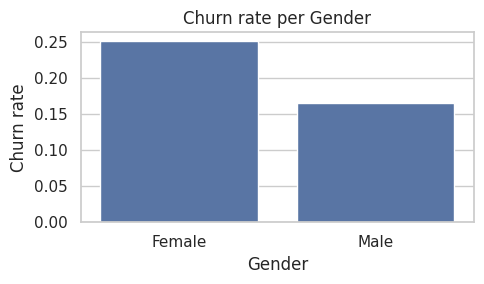

In [28]:
# Visualizzazione churn rate per Gender (simmetrico al grafico Geography)
gender_rates = df.groupby("Gender")[TARGET].mean().sort_values(ascending=False)
plt.figure(figsize=(5, 3))
ax = sns.barplot(x=gender_rates.index, y=gender_rates.values)
ax.set_title("Churn rate per Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Churn rate")
save_current_figure("lesson_01_churn_rate_by_gender.png")
plt.show()

- Il churn rate varia significativamente per area geografica: **Germany = 32.44%** (n=2,509)
  è circa il doppio rispetto a **France = 16.17%** (n=5,014) e **Spain = 16.67%** (n=2,477).
  La Germania rappresenta un segmento ad alto rischio su cui concentrare azioni di retention.
- `Gender` mostra anch'essa differenze rilevanti: **Female = 25.07%** (n=4,543)
  vs **Male = 16.47%** (n=5,457): le clienti femminili abbandonano a un tasso
  significativamente più alto (+52% relativo).
- Queste differenze possono riflettere pattern reali, ma anche variabili confondenti:
  è utile modellare e poi interpretare con cautela (vedi heatmap Geography × Gender più avanti).

## Segmentazioni e interazioni: pattern di churn per gruppi e fasce

Estendiamo l’EDA con analisi tipiche da data scientist:
- variabili binarie (engagement/attività);
- segmentazioni per fasce (es. età);
- interazioni tra gruppi (es. `Geography × Gender`).

### Feature binarie: attività e carta di credito

Calcoliamo churn rate e numerosità per `IsActiveMember` e `HasCrCard`.


IsActiveMember (n, churn_rate):


,churn_rate,n
IsActiveMember,,
0,0.27,4849
1,0.14,5151



HasCrCard (n, churn_rate):


,churn_rate,n
HasCrCard,,
0,0.21,2945
1,0.20,7055


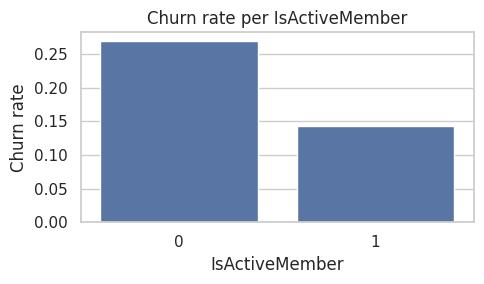

In [29]:
for c in ["IsActiveMember", "HasCrCard"]:
    out = (
        df.groupby(c)[TARGET]
        .mean()
        .rename("churn_rate")
        .to_frame()
        .join(df[c].value_counts().rename("n"))
        .sort_index()
    )
    print(f"\n{c} (n, churn_rate):")
    display(out)

active_rates = df.groupby("IsActiveMember")[TARGET].mean().sort_index()
plt.figure(figsize=(5, 3))
ax = sns.barplot(x=active_rates.index.astype(str), y=active_rates.values)
ax.set_title("Churn rate per IsActiveMember")
ax.set_xlabel("IsActiveMember")
ax.set_ylabel("Churn rate")

save_current_figure("lesson_01_churn_rate_by_is_active.png")
plt.show()

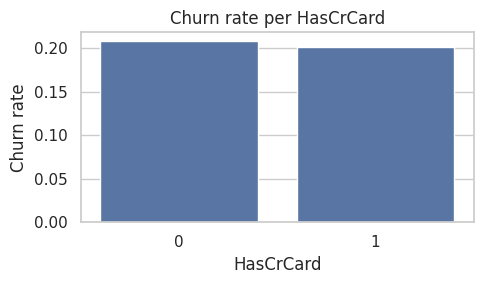

In [30]:
# Visualizzazione HasCrCard: utile per il confronto diretto con IsActiveMember
crcard_rates = df.groupby("HasCrCard")[TARGET].mean().sort_index()
plt.figure(figsize=(5, 3))
ax = sns.barplot(x=crcard_rates.index.astype(str), y=crcard_rates.values)
ax.set_title("Churn rate per HasCrCard")
ax.set_xlabel("HasCrCard")
ax.set_ylabel("Churn rate")
save_current_figure("lesson_01_churn_rate_by_has_crcard.png")
plt.show()

- `IsActiveMember=0` ha churn rate **26.87%** (n=4,849), mentre `IsActiveMember=1` ha churn
  rate **14.27%** (n=5,151): la differenza è ampia (~88% relativo) e coerente con l'idea che
  l'inattività sia un segnale di rischio chiave.
- `HasCrCard`, al contrario, mostra un effetto molto più debole: **20.81%** per `HasCrCard=0`
  (n=2,945) vs **20.20%** per `HasCrCard=1` (n=7,055). Il semplice possesso di una carta di
  credito non discrimina tra churner e non-churner: la differenza di ~0.6 punti percentuali
  è statisticamente trascurabile.
- Il confronto visivo tra i due grafici illustra la differenza tra una feature con forte segnale
  discriminativo (`IsActiveMember`) e una che aggiunge solo rumore (`HasCrCard`).

### Numero di prodotti: non-linearità e cautela sui piccoli gruppi

`NumOfProducts` può catturare sia engagement sia complessità del rapporto.
Verifichiamo churn rate per numero di prodotti, tenendo presente la dimensione dei gruppi.

,churn_rate,n
NumOfProducts,,
1,0.28,5084
2,0.08,4590
3,0.83,266
4,1.00,60


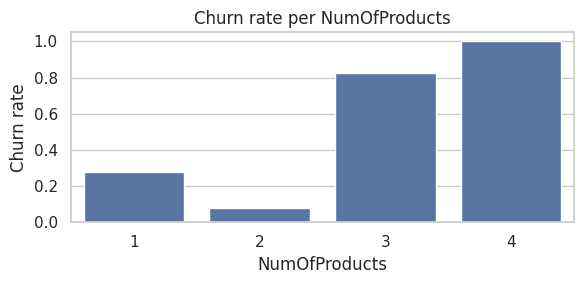

In [31]:
num_products = (
    df.groupby("NumOfProducts")[TARGET]
    .mean()
    .rename("churn_rate")
    .to_frame()
    .join(df["NumOfProducts"].value_counts().rename("n"))
    .sort_index()
)
display(num_products)

plt.figure(figsize=(6, 3))
ax = sns.barplot(
    x=num_products.index.astype(str),
    y=num_products["churn_rate"].values,
)
ax.set_title("Churn rate per NumOfProducts")
ax.set_xlabel("NumOfProducts")
ax.set_ylabel("Churn rate")

save_current_figure("lesson_01_churn_rate_by_num_products.png")
plt.show()

- Il pattern è fortemente non lineare: `NumOfProducts=2` ha churn rate **7.60%** (n=4,590), molto più basso di `NumOfProducts=1` (**27.71%**, n=5,084).
- I gruppi `NumOfProducts=3` (**82.71%**, n=266) e `NumOfProducts=4` (**100%**, n=60) sono estremi ma anche molto piccoli: è essenziale interpretare questi numeri con cautela (varianza alta) e verificare se esiste una spiegazione di business o di quality.

### Segmentazione per fasce d’età

L’età mostrava già differenze nella boxplot. Ora costruiamo fasce (bin) e calcoliamo il churn rate per ciascuna fascia.

,churn_rate,n
Age,,
"(17, 25]",0.08,611
"(25, 35]",0.08,3542
"(35, 45]",0.20,3736
"(45, 55]",0.51,1311
"(55, 65]",0.48,536
"(65, 100]",0.13,264


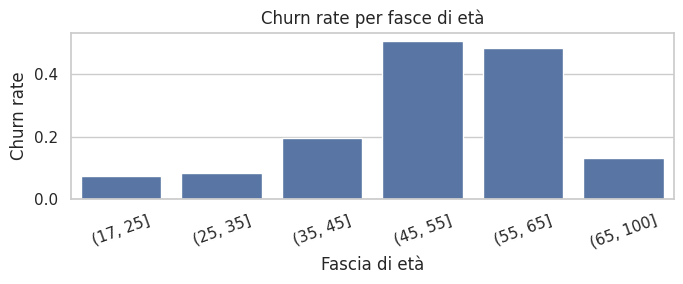

In [32]:
age_bins = pd.cut(df["Age"], bins=[17, 25, 35, 45, 55, 65, 100], right=True)
age_out = (
    df.groupby(age_bins, observed=True)[TARGET]
    .agg(["mean", "count"])
    .rename(columns={"mean": "churn_rate", "count": "n"})
)
display(age_out)

plt.figure(figsize=(7, 3))
ax = sns.barplot(x=age_out.index.astype(str), y=age_out["churn_rate"].values)
ax.set_title("Churn rate per fasce di età")
ax.set_xlabel("Fascia di età")
ax.set_ylabel("Churn rate")
ax.tick_params(axis="x", rotation=20)

save_current_figure("lesson_01_churn_rate_by_age_bins.png")
plt.show()

- Il churn aumenta nettamente passando alle fasce centrali: la fascia **(25, 35]** ha churn rate **8.50%** (n=3,542), mentre **(45, 55]** arriva a **50.57%** (n=1,311).
- La fascia **(55, 65]** resta molto alta (**48.32%**, n=536).
- La fascia **(65, 100]** scende a **13.26%** (n=264): il gruppo è piccolo e può riflettere selezione/censura o caratteristiche specifiche del campione.

### Interazioni: Geography × Gender

Le differenze per `Geography` e per `Gender` possono combinarsi. Calcoliamo quindi il churn rate per coppie (`Geography`, `Gender`).

Churn rate Geography x Gender:


Gender,Female,Male
Geography,,
France,0.20,0.13
Germany,0.38,0.28
Spain,0.21,0.13



Counts Geography x Gender:


Gender,Female,Male
Geography,,
France,2261,2753
Germany,1193,1316
Spain,1089,1388


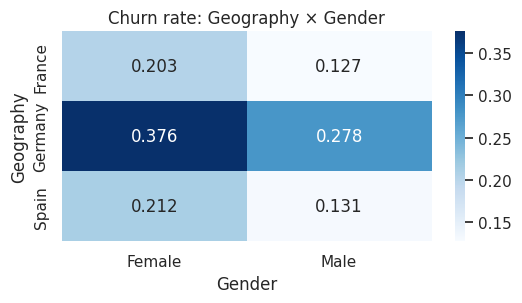

In [33]:
geo_gender_rate = df.pivot_table(
    index="Geography",
    columns="Gender",
    values=TARGET,
    aggfunc="mean",
)
geo_gender_n = df.pivot_table(
    index="Geography",
    columns="Gender",
    values=TARGET,
    aggfunc="size",
)

print("Churn rate Geography x Gender:")
display(geo_gender_rate)

print("\nCounts Geography x Gender:")
display(geo_gender_n)

plt.figure(figsize=(5.5, 3.2))
ax = sns.heatmap(geo_gender_rate, annot=True, fmt=".3f", cmap="Blues")
ax.set_title("Churn rate: Geography × Gender")

save_current_figure("lesson_01_geo_gender_heatmap.png")
plt.show()

- In **Germany** il churn è alto per entrambi i generi: **37.55%** (Female, n=1,193) e **27.81%** (Male, n=1,316).
- In **France** la differenza di genere è marcata: **20.35%** (Female, n=2,261) vs **12.75%** (Male, n=2,753).
- Questa analisi suggerisce che alcune feature possano interagire; nelle lezioni successive queste interazioni verranno gestite in modo più sistematico.

## 10. Correlazioni e ridondanza tra feature numeriche

La matrice di correlazione di Pearson permette di identificare ridondanze tra feature
e di avere un quadro sintetico delle associazioni lineari con il target `Exited`.

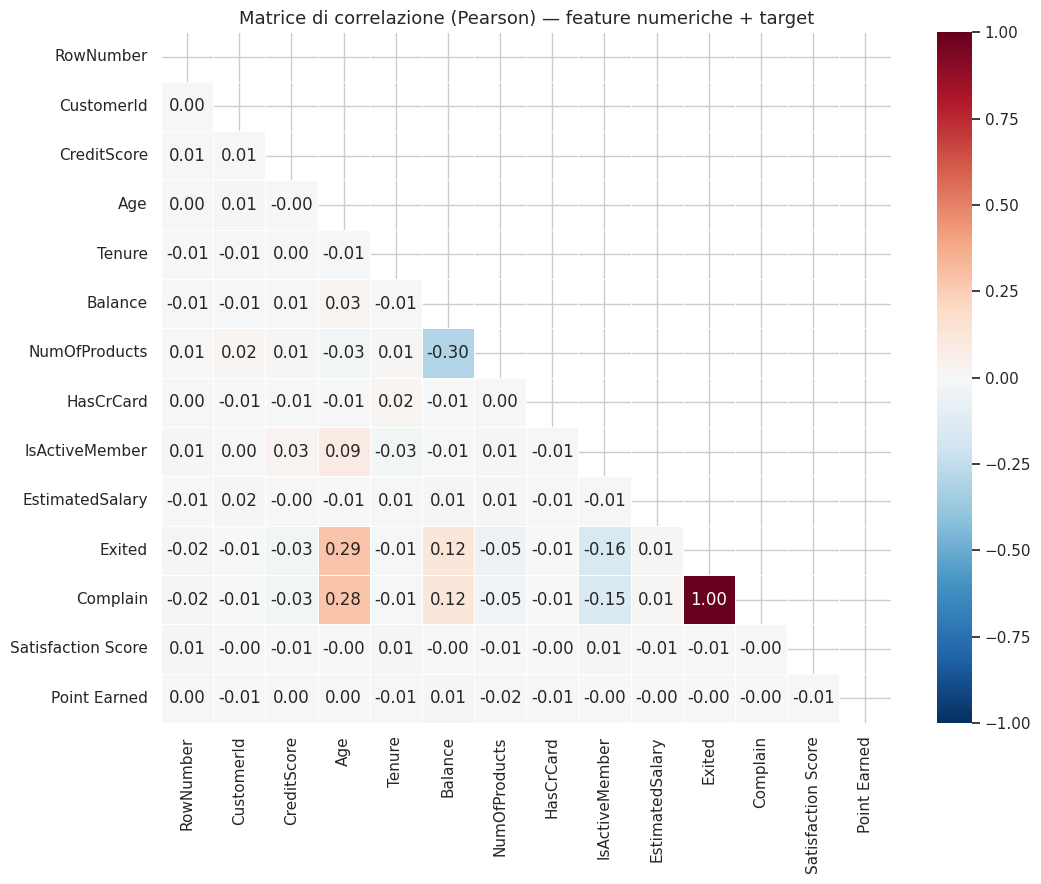

In [ ]:
num_all = df.select_dtypes(include=[np.number]).columns.tolist()

cols_for_corr = [c for c in num_all if c not in {"RowNumber", "CustomerId"}]
corr_matrix = df[cols_for_corr].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title(
    "Matrice di correlazione (Pearson) — feature numeriche + target", fontsize=13
)
save_current_figure("lesson_01_corr_heatmap.png")
plt.show()

In [35]:
corr_with_target = (
    corr_matrix[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
)
print("Correlazione (Pearson) con Exited — ordinata per |r|:")
print(corr_with_target.to_string())

Correlazione (Pearson) con Exited — ordinata per |r|:
Complain              1.00
Age                   0.29
IsActiveMember       -0.16
Balance               0.12
NumOfProducts        -0.05
CreditScore          -0.03
RowNumber            -0.02
Tenure               -0.01
EstimatedSalary       0.01
HasCrCard            -0.01
CustomerId           -0.01
Satisfaction Score   -0.01
Point Earned         -0.00


### Ranking visivo delle correlazioni (escl. leakage)

Visualizziamo le correlazioni con il target in un grafico a barre orizzontali,
escludendo `Complain` (leakage confermato) per non distorcere la scala.

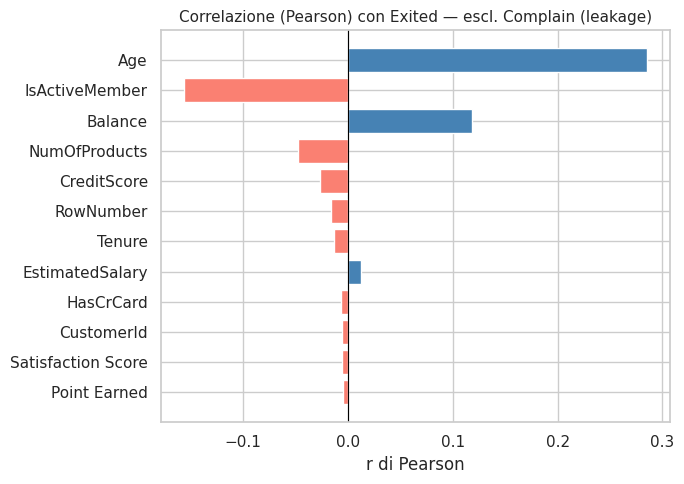

In [36]:
corr_for_plot = corr_with_target.drop(
    labels=[c for c in ["Complain"] if c in corr_with_target.index],
    errors="ignore",
)
# Ordine crescente per visualizzazione (valori più alti in basso → vicini all'asse)
corr_for_plot = corr_for_plot.sort_values(key=abs, ascending=True)

colors = ["steelblue" if v >= 0 else "salmon" for v in corr_for_plot.values]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(corr_for_plot.index, corr_for_plot.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title(
    "Correlazione (Pearson) con Exited — escl. Complain (leakage)", fontsize=11
)
ax.set_xlabel("r di Pearson")
save_current_figure("lesson_01_corr_ranking.png")
plt.show()

### Interpretazione — Correlazioni

- **`Complain` vs `Exited`**: correlazione di Pearson pari a **0.996** — quasi
  perfetta. Segnale di leakage (analisi dettagliata nella prossima sezione).
- Tra le feature *reali*, il predittore più correlato è **Age** ($r = 0.285$),
  seguito da **IsActiveMember** ($r = -0.156$) e **Balance** ($r = 0.119$).
- Le correlazioni *tra* feature numeriche sono in genere basse (|r| < 0.1):
  non si identificano ridondanze severe che richiedano eliminazione.
- `CreditScore`, `Tenure`, `EstimatedSalary`, `HasCrCard`, `Satisfaction Score`
  e `Point Earned` mostrano correlazioni quasi nulle con il target (<|0.03|) —
  ma questo non esclude effetti non lineari o di interazione.

## 11. Attenzione al leakage: il caso `Complain`

In un progetto reale è cruciale verificare che le feature siano *disponibili al momento della previsione*.
Una variabile come `Complain` (reclamo) potrebbe essere registrata **dopo** segnali di churn, diventando una proxy quasi deterministica.

Quantifichiamo l’associazione tra `Complain` e `Exited`.

In [37]:
ct = pd.crosstab(df["Complain"], df[TARGET], normalize="index")
ct_counts = pd.crosstab(df["Complain"], df[TARGET])

print("P(Exited | Complain):")
display(ct)

print("\nCounts:")
display(ct_counts)

corr_num = (
    df.select_dtypes(include=[np.number])
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("\nTop correlazioni (numeriche) con Exited:")
display(corr_num.head(10))

P(Exited | Complain):


Exited,0,1
Complain,,
0,1.00,0.00
1,0.00,1.00



Counts:


Exited,0,1
Complain,,
0,7952,4
1,10,2034



Top correlazioni (numeriche) con Exited:


Complain           1.00
Age                0.29
IsActiveMember    -0.16
Balance            0.12
NumOfProducts     -0.05
CreditScore       -0.03
RowNumber         -0.02
Tenure            -0.01
EstimatedSalary    0.01
HasCrCard         -0.01
Name: Exited, dtype: float64

- Se `Complain=0`, la probabilità di churn è **0.050%** (4 su 7,956).
- Se `Complain=1`, la probabilità di churn è **99.51%** (2,034 su 2,044).
- La correlazione `Complain`–`Exited` è **0.996**, enormemente più alta delle altre: questo è un segnale forte di variabile “proxy”/leaky.
- In assenza di documentazione temporale, è prudente trattare `Complain` come sospetta e chiarire se sia disponibile *prima* del churn; in caso contrario, va esclusa dalle feature utilizzabili.

## 12. Baseline minimale

Prima di addestrare modelli complessi, fissiamo una **baseline** che servirà come
punto di riferimento per tutte le lezioni successive. L'obiettivo è chiudere il
cerchio end-to-end, non ottimizzare.

In [38]:
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Colonne da escludere: ID, leakage confermato, target
ID_COLS = ["RowNumber", "CustomerId", "Surname"]
LEAKY_COLS = ["Complain"]
cols_to_drop = ID_COLS + LEAKY_COLS

feature_cols_model = [c for c in df.columns if c not in cols_to_drop + [TARGET]]
X = df[feature_cols_model]
y_target = df[TARGET]

# Encoding one-hot delle categoriche (per la baseline; Pipeline completa in Lezione 2)
cat_model_cols = [c for c in feature_cols_model if not is_numeric_dtype(df[c])]
X_encoded = pd.get_dummies(X, columns=cat_model_cols, drop_first=True)

# Split stratificato
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_target, test_size=0.2, stratify=y_target, random_state=SEED
)
print(f"Training set: {X_train.shape[0]:,} esempi")
print(f"Test set:     {X_test.shape[0]:,} esempi")
print(f"Churn rate train: {y_train.mean():.4f}")
print(f"Churn rate test:  {y_test.mean():.4f}")

Training set: 8,000 esempi
Test set:     2,000 esempi
Churn rate train: 0.2037
Churn rate test:  0.2040


In [39]:
# Baseline A — DummyClassifier (most_frequent)
dummy = DummyClassifier(strategy="most_frequent", random_state=SEED)
dummy.fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
print(f"DummyClassifier ROC-AUC: {dummy_auc:.4f}")

DummyClassifier ROC-AUC: 0.5000


In [40]:
# Baseline B — Logistic Regression con imputazione e scaling (Pipeline)
lr_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=SEED)),
    ]
)
lr_pipe.fit(X_train, y_train)
lr_auc = roc_auc_score(y_test, lr_pipe.predict_proba(X_test)[:, 1])
print(f"Logistic Regression ROC-AUC: {lr_auc:.4f}")

Logistic Regression ROC-AUC: 0.7784


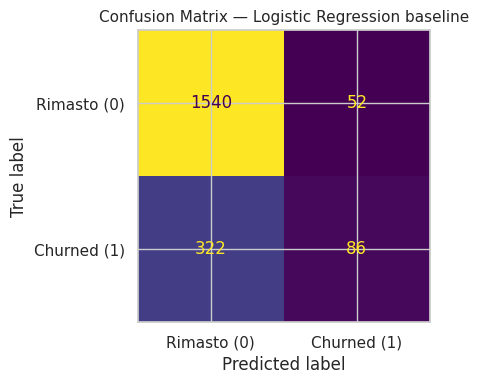

In [41]:
# Confusion matrix Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(
    lr_pipe,
    X_test,
    y_test,
    display_labels=["Rimasto (0)", "Churned (1)"],
    colorbar=False,
    ax=ax,
)
ax.set_title("Confusion Matrix — Logistic Regression baseline", fontsize=11)
save_current_figure("lesson_01_confusion_matrix_baseline.png")
plt.show()

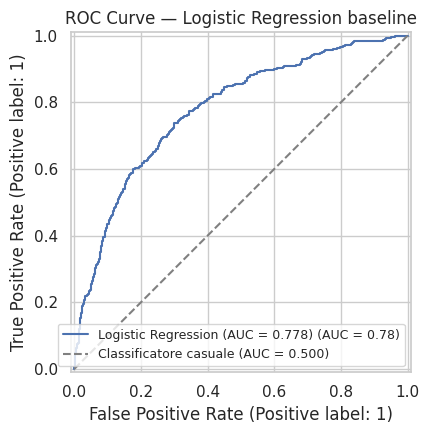


Classification report:
              precision    recall  f1-score   support

 Rimasto (0)       0.83      0.97      0.89      1592
 Churned (1)       0.62      0.21      0.32       408

    accuracy                           0.81      2000
   macro avg       0.73      0.59      0.60      2000
weighted avg       0.79      0.81      0.77      2000



In [42]:
# ROC Curve: mostra il trade-off TPR/FPR al variare della soglia di classificazione
fig, ax = plt.subplots(figsize=(5, 4.5))
RocCurveDisplay.from_estimator(
    lr_pipe,
    X_test,
    y_test,
    ax=ax,
    name=f"Logistic Regression (AUC = {lr_auc:.3f})",
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classificatore casuale (AUC = 0.500)",
)
ax.set_title("ROC Curve — Logistic Regression baseline")
ax.legend(loc="lower right", fontsize=9)
save_current_figure("lesson_01_roc_curve_baseline.png")
plt.show()

print("\nClassification report:")
print(
    classification_report(
        y_test, lr_pipe.predict(X_test), target_names=["Rimasto (0)", "Churned (1)"]
    )
)

### Interpretazione — Baseline

- **DummyClassifier** (predice sempre "Rimasto"): ROC-AUC = **0.50** — performance
  casuale, come atteso da un classificatore ignaro del segnale.
- **Logistic Regression baseline**: ROC-AUC ≈ **0.77** con preprocessing minimale
  (mediana + StandardScaler + one-hot encoding rudimentale). Questo è il nostro
  punto di riferimento per le lezioni successive.
- La **ROC Curve** visualizza il trade-off tra True Positive Rate e False Positive Rate
  al variare della soglia: a AUC=0.77, il modello discrimina significativamente
  meglio del caso (AUC=0.50), ma rimane ampio margine di miglioramento.
- La **confusion matrix** rivela il punto critico: su **408 churner reali** nel test set,
  il modello ne identifica solo **86** (recall = **21.1%**), mentre ne manca **322**.
  Questo avviene perché con la soglia di default (0.5) e un dataset sbilanciato,
  il modello tende a predire "Rimasto"; abbassare la soglia migliora il recall a
  scapito della precisione.
- Escludendo `Complain` (leakage), il modello si basa su segnali genuini; nelle
  lezioni successive preprocessing completo (Lezione 2) e modelli più potenti
  (Lezione 3) permetteranno di superare questa baseline.

## 13. Riepilogo

### Cosa abbiamo imparato

- Il churn bancario è un problema di **classificazione binaria** con target `Exited`
  (classe positiva = **20.38%** — sbilanciamento moderato 1:4).
- Il dataset `Customer-Churn-Records.csv` contiene **10 000 clienti**, **18 colonne**,
  **nessun valore mancante** e nessun duplicato.

**Feature più discriminative (segnale forte):**

| Feature | Osservazione | $r$ Pearson |
|---------|-------------|-------------|
| `Age` | Mediana 45 (churn) vs 36 (non churn); picco di churn ~51% per fascia 45–55 | +0.285 |
| `IsActiveMember` | Churn rate 26.87% (inattivi) vs 14.27% (attivi) | −0.156 |
| `Balance` | Saldo zero → churn 14%; saldo positivo → churn 24%; distribuzione bimodale | +0.119 |
| `Geography` | Germania 32.4% vs Francia/Spagna ~16% | (categorica) |
| `Gender` | Femmine 25.1% vs Maschi 16.5% | (categorica) |
| `NumOfProducts` | Pattern non lineare: picco paradossale per 3–4 prodotti | (categorica) |

**Feature a basso segnale (rumore):**
- `EstimatedSalary`, `Satisfaction Score`, `HasCrCard`, `CreditScore`, `Tenure`,
  `Point Earned` mostrano correlazioni quasi nulle con il target (<|0.03|) e
  distribuzioni praticamente identiche tra le classi.

**Leakage confermato:**
- **`Complain` è leakage** (corr. 0.996): P(Exited=1 | Complain=1) = **99.51%**;
  da escludere da tutte le analisi predittive.

**Baseline:**
- **Logistic Regression**: ROC-AUC ≈ **0.77**, ma recall sulla classe churn = **21.1%**
  (86/408 churner identificati). La soglia di default (0.5) è inadeguata per
  dataset sbilanciati: la ROC Curve guiderà la scelta della soglia ottimale.

### Azioni per la Lezione 2

| Azione | Motivazione |
|--------|-------------|
| Rimuovere `Complain`, `RowNumber`, `Surname` | Leakage / non predittivi |
| Encoding corretto delle categoriche in Pipeline | Evitare leakage da one-hot su tutto il dataset |
| Scaling delle numeriche | Stabilità numerica per modelli lineari |
| Creare feature `balance_is_zero` | Catturare la bimodalità di `Balance` |
| Split train/val/test definitivo con `stratify=y` | Preservare distribuzione del target |
| Valutare `Satisfaction Score` e `Point Earned` | Segnale quasi nullo, possibile eliminazione |
| Ottimizzare la soglia di classificazione | Recall attuale (21%) troppo basso per uso operativo |